# Data Exploration - Assignment 1

This notebook performs exploratory data analysis on the smoking/drinking dataset:
- smoking_driking_dataset_Ver01.csv

## Task 1: Data Exploration
a. Explore dataset by displaying first few rows, summary statistics, and data types
b. Identify missing values, outliers, and unique values in categorical columns

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configure display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
warnings.filterwarnings('ignore')

# Set matplotlib style
plt.style.use('default')
sns.set_palette("husl")

In [3]:
# Load the smoking/drinking dataset
smoking_drinking_df = pd.read_csv('../data/raw/smoking_driking_dataset_Ver01.csv')

print("Dataset loaded successfully!")
print(f"Smoking/Drinking dataset shape: {smoking_drinking_df.shape}")

Dataset loaded successfully!
Smoking/Drinking dataset shape: (991346, 24)


## Smoking/Drinking Dataset Exploration

In [8]:
# a. Display first few rows of smoking/drinking dataset
print("=== FIRST 5 ROWS OF SMOKING/DRINKING DATASET ===")
print(smoking_drinking_df.head())
print("\n" + "="*50 + "\n")

=== FIRST 5 ROWS OF SMOKING/DRINKING DATASET ===
    sex  age  height  weight  waistline  sight_left  sight_right  hear_left  \
0  Male   35     170      75       90.0         1.0          1.0        1.0   
1  Male   30     180      80       89.0         0.9          1.2        1.0   
2  Male   40     165      75       91.0         1.2          1.5        1.0   
3  Male   50     175      80       91.0         1.5          1.2        1.0   
4  Male   50     165      60       80.0         1.0          1.2        1.0   

   hear_right    SBP   DBP   BLDS  tot_chole  HDL_chole  LDL_chole  \
0         1.0  120.0  80.0   99.0      193.0       48.0      126.0   
1         1.0  130.0  82.0  106.0      228.0       55.0      148.0   
2         1.0  120.0  70.0   98.0      136.0       41.0       74.0   
3         1.0  145.0  87.0   95.0      201.0       76.0      104.0   
4         1.0  138.0  82.0  101.0      199.0       61.0      117.0   

   triglyceride  hemoglobin  urine_protein  serum_creat

In [9]:
# Display data types and basic information
print("=== DATA TYPES AND INFO - SMOKING/DRINKING DATASET ===")
print(smoking_drinking_df.info())
print("\n=== DATA TYPES ===")
print(smoking_drinking_df.dtypes)
print("\n" + "="*50 + "\n")

=== DATA TYPES AND INFO - SMOKING/DRINKING DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 991346 entries, 0 to 991345
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   sex               991346 non-null  object 
 1   age               991346 non-null  int64  
 2   height            991346 non-null  int64  
 3   weight            991346 non-null  int64  
 4   waistline         991346 non-null  float64
 5   sight_left        991346 non-null  float64
 6   sight_right       991346 non-null  float64
 7   hear_left         991346 non-null  float64
 8   hear_right        991346 non-null  float64
 9   SBP               991346 non-null  float64
 10  DBP               991346 non-null  float64
 11  BLDS              991346 non-null  float64
 12  tot_chole         991346 non-null  float64
 13  HDL_chole         991346 non-null  float64
 14  LDL_chole         991346 non-null  float64
 15  triglyceride 

In [10]:
# Display summary statistics
print("=== SUMMARY STATISTICS - SMOKING/DRINKING DATASET ===")
print(smoking_drinking_df.describe())
print("\n=== SUMMARY STATISTICS (INCLUDING NON-NUMERIC) ===")
print(smoking_drinking_df.describe(include='all'))
print("\n" + "="*50 + "\n")

=== SUMMARY STATISTICS - SMOKING/DRINKING DATASET ===
                 age         height         weight      waistline  \
count  991346.000000  991346.000000  991346.000000  991346.000000   
mean       47.614491     162.240625      63.284050      81.233358   
std        14.181339       9.282957      12.514241      11.850323   
min        20.000000     130.000000      25.000000       8.000000   
25%        35.000000     155.000000      55.000000      74.100000   
50%        45.000000     160.000000      60.000000      81.000000   
75%        60.000000     170.000000      70.000000      87.800000   
max        85.000000     190.000000     140.000000     999.000000   

          sight_left    sight_right      hear_left     hear_right  \
count  991346.000000  991346.000000  991346.000000  991346.000000   
mean        0.980834       0.978429       1.031495       1.030476   
std         0.605949       0.604774       0.174650       0.171892   
min         0.100000       0.100000       1.0000

In [11]:
# b. Identify missing values
print("=== MISSING VALUES - SMOKING/DRINKING DATASET ===")
missing_values = smoking_drinking_df.isnull().sum()
missing_percentage = (missing_values / len(smoking_drinking_df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) > 0:
    print("Columns with missing values:")
    print(missing_df)
else:
    print("No missing values found in the smoking/drinking dataset!")
    
print("\n" + "="*50 + "\n")

=== MISSING VALUES - SMOKING/DRINKING DATASET ===
No missing values found in the smoking/drinking dataset!




In [12]:
# Identify unique values in categorical columns
print("=== CATEGORICAL COLUMNS AND UNIQUE VALUES - SMOKING/DRINKING DATASET ===")

# Identify categorical columns (object type and low-cardinality numeric columns)
categorical_cols = smoking_drinking_df.select_dtypes(include=['object']).columns.tolist()

# Also check for numeric columns that might be categorical (low unique values)
numeric_cols = smoking_drinking_df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    unique_count = smoking_drinking_df[col].nunique()
    if unique_count <= 10:  # Consider numeric columns with ≤10 unique values as potentially categorical
        categorical_cols.append(col)

print(f"Identified categorical columns: {categorical_cols}")
print("\nUnique values in each categorical column:")
for col in categorical_cols:
    unique_vals = smoking_drinking_df[col].unique()
    print(f"\n{col}:")
    print(f"  Number of unique values: {len(unique_vals)}")
    print(f"  Unique values: {unique_vals}")
    print(f"  Value counts:")
    print(smoking_drinking_df[col].value_counts())

print("\n" + "="*50 + "\n")

=== CATEGORICAL COLUMNS AND UNIQUE VALUES - SMOKING/DRINKING DATASET ===
Identified categorical columns: ['sex', 'DRK_YN', 'hear_left', 'hear_right', 'urine_protein', 'SMK_stat_type_cd']

Unique values in each categorical column:

sex:
  Number of unique values: 2
  Unique values: ['Male' 'Female']
  Value counts:
sex
Male      526415
Female    464931
Name: count, dtype: int64

DRK_YN:
  Number of unique values: 2
  Unique values: ['Y' 'N']
  Value counts:
DRK_YN
N    495858
Y    495488
Name: count, dtype: int64

hear_left:
  Number of unique values: 2
  Unique values: [1. 2.]
  Value counts:
hear_left
1.0    960124
2.0     31222
Name: count, dtype: int64

hear_right:
  Number of unique values: 2
  Unique values: [1. 2.]
  Value counts:
hear_right
1.0    961134
2.0     30212
Name: count, dtype: int64

urine_protein:
  Number of unique values: 6
  Unique values: [1. 3. 2. 4. 5. 6.]
  Value counts:
urine_protein
1.0    935175
2.0     30850
3.0     16405
4.0      6427
5.0      1977
6.0   

In [13]:
# Identify outliers in numeric columns using IQR method
print("=== OUTLIER DETECTION - SMOKING/DRINKING DATASET ===")

numeric_cols = smoking_drinking_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns for outlier detection: {numeric_cols}")

outlier_summary = {}

for col in numeric_cols:
    Q1 = smoking_drinking_df[col].quantile(0.25)
    Q3 = smoking_drinking_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = smoking_drinking_df[(smoking_drinking_df[col] < lower_bound) | (smoking_drinking_df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(smoking_drinking_df)) * 100
    
    outlier_summary[col] = {
        'count': outlier_count,
        'percentage': outlier_percentage,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound
    }
    
    print(f"\n{col}:")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
    print(f"  Outliers: {outlier_count} ({outlier_percentage:.1f}%)")
    
    if outlier_count > 0:
        print(f"  Min outlier value: {smoking_drinking_df[col][(smoking_drinking_df[col] < lower_bound) | (smoking_drinking_df[col] > upper_bound)].min():.2f}")
        print(f"  Max outlier value: {smoking_drinking_df[col][(smoking_drinking_df[col] < lower_bound) | (smoking_drinking_df[col] > upper_bound)].max():.2f}")

print("\n" + "="*50 + "\n")

=== OUTLIER DETECTION - SMOKING/DRINKING DATASET ===
Numeric columns for outlier detection: ['age', 'height', 'weight', 'waistline', 'sight_left', 'sight_right', 'hear_left', 'hear_right', 'SBP', 'DBP', 'BLDS', 'tot_chole', 'HDL_chole', 'LDL_chole', 'triglyceride', 'hemoglobin', 'urine_protein', 'serum_creatinine', 'SGOT_AST', 'SGOT_ALT', 'gamma_GTP', 'SMK_stat_type_cd']

age:
  Q1: 35.00, Q3: 60.00, IQR: 25.00
  Lower bound: -2.50, Upper bound: 97.50
  Outliers: 0 (0.0%)

height:
  Q1: 155.00, Q3: 170.00, IQR: 15.00
  Lower bound: 132.50, Upper bound: 192.50
  Outliers: 86 (0.0%)
  Min outlier value: 130.00
  Max outlier value: 130.00

weight:
  Q1: 55.00, Q3: 70.00, IQR: 15.00
  Lower bound: 32.50, Upper bound: 92.50
  Outliers: 19221 (1.9%)
  Min outlier value: 25.00
  Max outlier value: 140.00

waistline:
  Q1: 74.10, Q3: 87.80, IQR: 13.70
  Lower bound: 53.55, Upper bound: 108.35
  Outliers: 4417 (0.4%)
  Min outlier value: 8.00
  Max outlier value: 999.00

sight_left:
  Q1: 0.70,

=== HISTOGRAMS OF NUMERIC COLUMNS - SMOKING/DRINKING DATASET ===


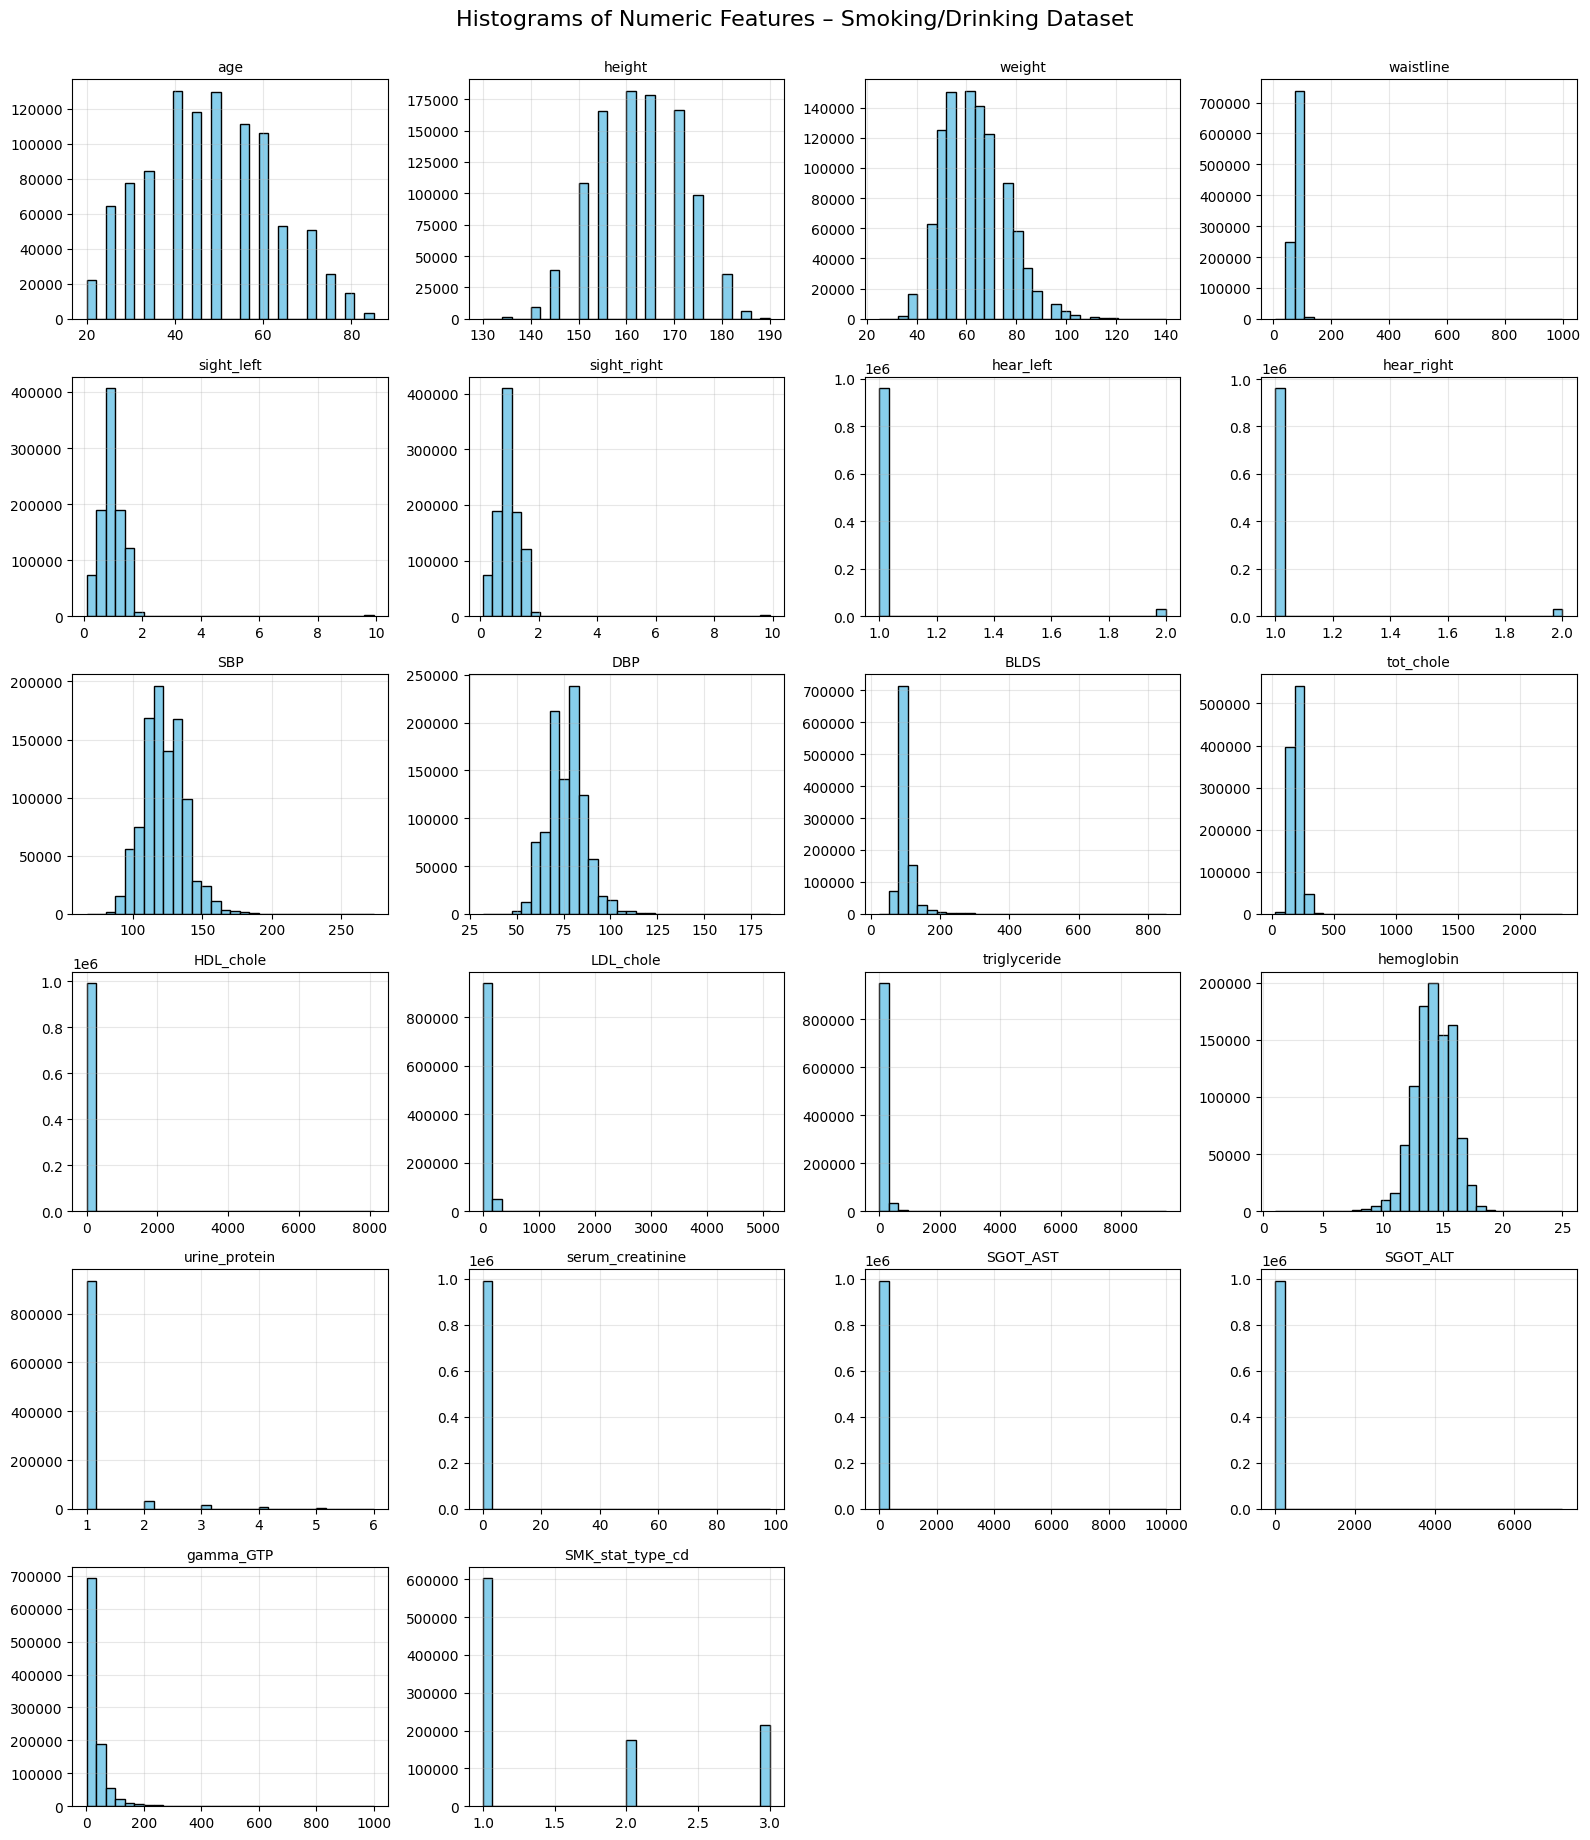

In [8]:
# Histogram plots for numeric columns
print("=== HISTOGRAMS OF NUMERIC COLUMNS - SMOKING/DRINKING DATASET ===")
# Select only numeric columns
numeric_cols = smoking_drinking_df.select_dtypes(include=[np.number]).columns

# How many subplots?
n_cols = 4  # number of plots per row
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

plt.figure(figsize=(16, n_rows * 3))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(smoking_drinking_df[col].dropna(), bins=30, color="skyblue", edgecolor="black")
    plt.title(col, fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()

plt.suptitle("Histograms of Numeric Features – Smoking/Drinking Dataset", fontsize=16, y=1.02)
plt.show()

Skewness of numeric columns:
age                   0.153653
height               -0.022737
weight                0.576557
waistline            26.788440
sight_left            9.994626
sight_right          10.033647
hear_left             5.365084
hear_right            5.463013
SBP                   0.482060
DBP                   0.400034
BLDS                  4.617377
tot_chole             1.556882
HDL_chole           104.577635
LDL_chole             5.251739
triglyceride          6.529373
hemoglobin           -0.383988
urine_protein         5.672491
serum_creatinine    111.022058
SGOT_AST            150.491690
SGOT_ALT             50.038872
gamma_GTP             7.718509
SMK_stat_type_cd      0.831428
dtype: float64


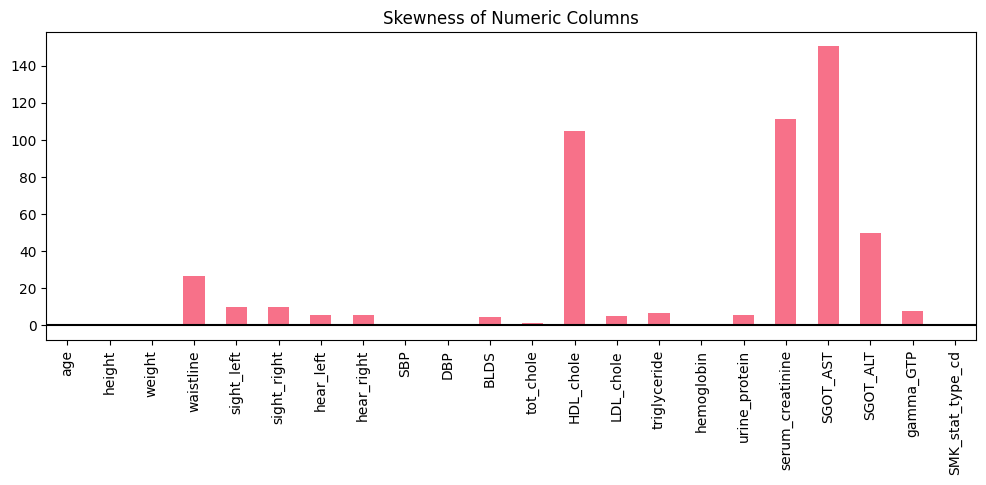

In [11]:
# Compute skewness for all numeric columns
skew_values = smoking_drinking_df.skew(numeric_only=True)

print("Skewness of numeric columns:")
print(skew_values)
skew_values.plot(kind='bar', figsize=(12,4), title="Skewness of Numeric Columns")
plt.axhline(0, color='black')
plt.show()

## Summary of Data Exploration

The data exploration has been completed for the smoking/drinking dataset. Key findings will be displayed after running all the cells above.

### What we analyzed:
1. **First few rows** - to understand the structure and content
2. **Data types** - to identify numeric vs categorical variables
3. **Summary statistics** - to understand distributions and central tendencies
4. **Missing values** - to identify data quality issues
5. **Categorical variables** - to understand unique values and their frequencies
6. **Outliers** - using the IQR method to identify potential anomalies

### Next steps:
After running all cells, review the output to understand:
- Dataset dimensions and structure
- Data quality issues (missing values, outliers)
- Distribution of categorical variables
- Summary statistics for numeric variables